In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
%pip install transformers datasets peft accelerate bitsandbytes openpyxl pandas scikit-learn trl matplotlib seaborn

Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   ----- ---------------------------------- 0.8/5.5 MB 3.0 MB/s eta 0:00:02
   --------------------- ------------------ 2.9/5.5 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 8.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 16.2 MB/s eta 0:02:55
   ---------------------------------------- 0.0/2.8 GB 13.5 MB/s eta 0:03:28
   ---------------------------------------- 0.0/2.8 GB 12.1 MB/s eta 0:03:53
   ---------------------------------------- 0.0/2.8 GB 13.6 MB/s eta 0:03:27
   ---------------------------------------- 0.0/2.8 GB 12.3 MB/s eta 0:03:49
   ---------------------------------------- 0.0/2.8 GB 12.1 MB/s eta 0:03:52
   ---------------------------------------- 0.0

In [3]:
# ============================================================================
# PART 1: INSTALLATION AND SETUP
# ============================================================================

# Run these in your terminal first:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# pip install transformers datasets peft accelerate bitsandbytes openpyxl pandas scikit-learn trl

import pandas as pd
import numpy as np
import torch
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA device: NVIDIA GeForce GTX 1650


In [9]:
# ============================================================================
# PART 2: DATA LOADING AND ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("LOADING AND ANALYZING DATA")
print("="*80)

# Load both datasets
df1 = pd.read_excel('Autism_Screening_Data_Combined.xlsx')
df2 = pd.read_excel('Toddler-Autism-dataset-July-2018.xlsx')

print(f"\nDataset 1 shape: {df1.shape}")
print(f"Dataset 2 shape: {df2.shape}")

# Display first few rows to understand structure
print("\nDataset 1 columns:", df1.columns.tolist())
print("\nDataset 2 columns:", df2.columns.tolist())
print("\nDataset 1 sample:\n", df1.head())
print("\nDataset 2 sample:\n", df2.head())

# Standardize column names for Dataset 1
print("\nStandardizing Dataset 1 columns...")
df1_renamed = df1.rename(columns={
    'Jauundice': 'Jaundice',  # Fix typo
    'Class': 'ASD_Result'
})

# Standardize column names for Dataset 2
print("Standardizing Dataset 2 columns...")
df2_renamed = df2.rename(columns={
    'Age_Mons': 'Age',
    'Family_mem_with_ASD': 'Family_ASD',
    'Class/ASD Traits ': 'ASD_Result'
})

print(f"DF1 columns after rename: {df1_renamed.columns.tolist()}")
print(f"DF2 columns after rename: {df2_renamed.columns.tolist()}")

# Select only the columns we need from each dataset
required_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 
                 'Age', 'Sex', 'Jaundice', 'Family_ASD', 'ASD_Result']

df1_selected = df1_renamed[required_cols].copy()
df2_selected = df2_renamed[required_cols].copy()

print(f"\nDF1 selected shape: {df1_selected.shape}")
print(f"DF2 selected shape: {df2_selected.shape}")

# Combine datasets
df_combined = pd.concat([df1_selected, df2_selected], ignore_index=True)

print(f"Combined before cleaning: {df_combined.shape}")

# Standardize ASD_Result values to YES/NO
df_combined['ASD_Result'] = df_combined['ASD_Result'].astype(str).str.strip().str.upper()
df_combined['ASD_Result'] = df_combined['ASD_Result'].replace({
    'YES': 'YES',
    'NO': 'NO',
    '1': 'YES',
    '0': 'NO',
    'TRUE': 'YES',
    'FALSE': 'NO'
})

# Drop rows with missing values
print(f"Missing values per column:\n{df_combined.isnull().sum()}")
df_combined = df_combined.dropna()

# Keep only YES/NO results
df_combined = df_combined[df_combined['ASD_Result'].isin(['YES', 'NO'])]

print(f"\nCombined dataset shape: {df_combined.shape}")
print(f"Available columns: {df_combined.columns.tolist()}")
print(f"\nFirst few rows of combined data:")
print(df_combined.head())
print(f"\nData types:\n{df_combined.dtypes}")
print(f"\nASD_Result unique values: {df_combined['ASD_Result'].unique()}")


LOADING AND ANALYZING DATA

Dataset 1 shape: (6075, 15)
Dataset 2 shape: (1054, 19)

Dataset 1 columns: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Sex', 'Jauundice', 'Family_ASD', 'Class']

Dataset 2 columns: ['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits ']

Dataset 1 sample:
    A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Sex Jauundice Family_ASD Class
0   1   1   0   1   0   0   1   1   0    0   15   m        no         no    NO
1   0   1   1   1   0   1   1   0   1    0   15   m        no         no    NO
2   1   1   1   0   1   1   1   1   1    1   15   f        no        yes   YES
3   1   1   1   1   1   1   1   1   0    0   16   f        no         no   YES
4   1   1   1   1   1   1   1   1   1    1   15   f        no         no   YES

Dataset 2 sample:
    Case_No  A1  A2  A3  A4  A5  A6  A7  A8  


DATA IMBALANCE ANALYSIS

ASD Result Distribution:
ASD_Result
NO     4597
YES    2532
Name: count, dtype: int64

Imbalance Ratio: 1.82:1


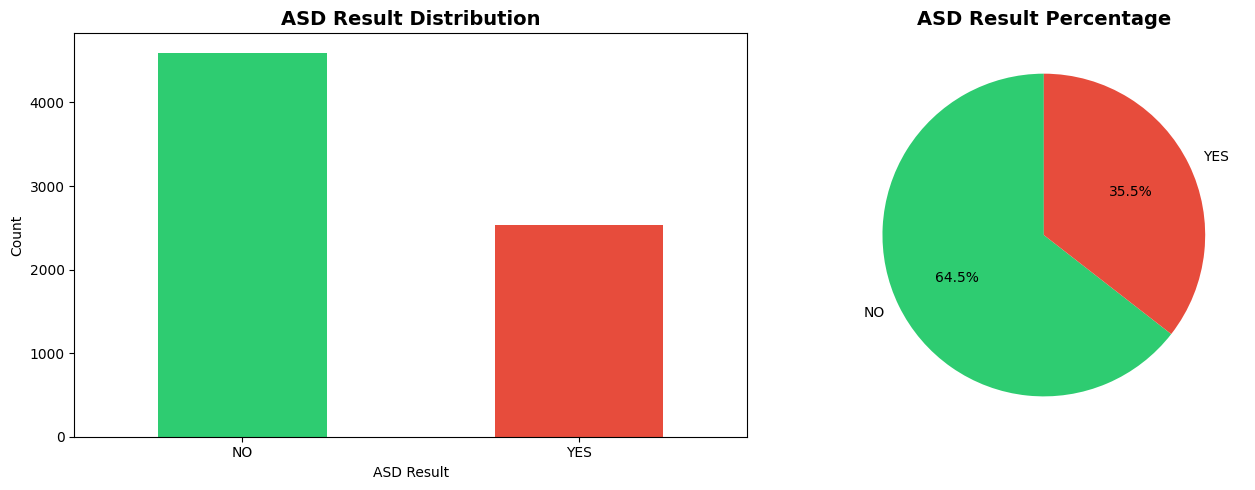


Total samples: 7129
NO: 4597 (64.5%)
YES: 2532 (35.5%)


In [10]:

# ============================================================================
# PART 3: DATA IMBALANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("DATA IMBALANCE ANALYSIS")
print("="*80)

# Analyze target variable
asd_counts = df_combined['ASD_Result'].value_counts()
print("\nASD Result Distribution:")
print(asd_counts)
print(f"\nImbalance Ratio: {asd_counts.max() / asd_counts.min():.2f}:1")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
asd_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('ASD Result Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ASD Result')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
axes[1].pie(asd_counts, labels=asd_counts.index, autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('ASD Result Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTotal samples: {len(df_combined)}")
for label, count in asd_counts.items():
    print(f"{label}: {count} ({count/len(df_combined)*100:.1f}%)")

In [11]:
# ============================================================================
# PART 4: PREPARE TRAINING DATA
# ============================================================================

print("\n" + "="*80)
print("PREPARING TRAINING DATA")
print("="*80)

questions = [
    "Does your child look at you when you call his/her name?",
    "How easy is it for you to get eye contact with your child?",
    "Does your child point to indicate that s/he wants something (e.g. a toy that is out of reach)?",
    "Does your child point to share interest with you (e.g. pointing at an interesting sight)?",
    "Does your child pretend (e.g. care for dolls, talk on a toy phone)?",
    "Does your child follow where you're looking?",
    "If you or someone else in the family is visibly upset, does your child show signs of wanting to comfort them?",
    "Would you describe your child's first words as clear and meaningful?",
    "Does your child use simple gestures (e.g. wave goodbye)?",
    "Does your child stare at nothing with no apparent purpose?"
]

def create_prompt(row):
    """Create a formatted prompt for the LLM"""
    prompt = "Patient screening info:\n"
    
    for i, q in enumerate(questions, 1):
        answer = row[f'A{i}']
        prompt += f"{q} Answer: {answer}\n"
    
    # Add demographic info
    age = row.get('Age', 'unknown')
    sex = row.get('Sex', 'unknown')
    jaundice = row.get('Jaundice', 'unknown')
    family_asd = row.get('Family_ASD', 'unknown')
    
    prompt += f"Age: {age}, Sex: {sex}, Jaundice: {jaundice}, Family history of ASD: {family_asd}\n\n"
    prompt += "Does this child have autism risk? Answer YES or NO."
    
    return prompt

def create_completion(row):
    """Create the completion (answer) for the LLM"""
    result = row['ASD_Result']
    # Normalize the result to YES/NO
    if str(result).lower() in ['yes', '1', 'true', 'positive']:
        return "YES"
    else:
        return "NO"

# Create prompts and completions
df_combined['prompt'] = df_combined.apply(create_prompt, axis=1)
df_combined['completion'] = df_combined.apply(create_completion, axis=1)

# Create full text for training
df_combined['text'] = df_combined.apply(
    lambda x: f"### Instruction:\n{x['prompt']}\n\n### Response:\n{x['completion']}", 
    axis=1
)

print(f"\nSample training example:\n{df_combined['text'].iloc[0]}")

# Split data
train_df, test_df = train_test_split(
    df_combined, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_combined['ASD_Result']
)

print(f"\nTraining samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# Save for later use
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)


PREPARING TRAINING DATA

Sample training example:
### Instruction:
Patient screening info:
Does your child look at you when you call his/her name? Answer: 1
How easy is it for you to get eye contact with your child? Answer: 1
Does your child point to indicate that s/he wants something (e.g. a toy that is out of reach)? Answer: 0
Does your child point to share interest with you (e.g. pointing at an interesting sight)? Answer: 1
Does your child pretend (e.g. care for dolls, talk on a toy phone)? Answer: 0
Does your child follow where you're looking? Answer: 0
If you or someone else in the family is visibly upset, does your child show signs of wanting to comfort them? Answer: 1
Would you describe your child's first words as clear and meaningful? Answer: 1
Does your child use simple gestures (e.g. wave goodbye)? Answer: 0
Does your child stare at nothing with no apparent purpose? Answer: 0
Age: 15, Sex: m, Jaundice: no, Family history of ASD: no

Does this child have autism risk? Answer Y

In [12]:
# ============================================================================
# PART 5: MODEL SETUP AND FINE-TUNING
# ============================================================================

print("\n" + "="*80)
print("SETTING UP MODEL FOR FINE-TUNING")
print("="*80)

from transformers import (
    AutoModelForCausalLM, 
    AutoTokenizer, 
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset

# Model selection - Phi-2 is small enough for 16GB RAM
model_name = "microsoft/phi-2"  # 2.7B parameters

print(f"\nLoading model: {model_name}")
print("This may take a few minutes...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load model with 8-bit quantization to save memory
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    load_in_8bit=True,
    device_map="auto",
    trust_remote_code=True
)

print("Model loaded successfully!")

# Prepare model for training
model = prepare_model_for_kbit_training(model)

# Configure LoRA (Low-Rank Adaptation) for efficient fine-tuning
lora_config = LoraConfig(
    r=16,  # Rank of the update matrices
    lora_alpha=32,  # Scaling factor
    target_modules=["Wqkv", "fc1", "fc2"],  # Phi-2 specific modules
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Tokenize datasets
def tokenize_function(examples):
    outputs = tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        padding='max_length'
    )
    outputs['labels'] = outputs['input_ids'].copy()
    return outputs

train_dataset = Dataset.from_pandas(train_df[['text']])
test_dataset = Dataset.from_pandas(test_df[['text']])

print("\nTokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
test_dataset = test_dataset.map(tokenize_function, batched=True, remove_columns=['text'])

# Data collator
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

# Training arguments
training_args = TrainingArguments(
    output_dir="./autism_screening_model",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    report_to="none"
)

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
)

print("\n" + "="*80)
print("STARTING FINE-TUNING")
print("="*80)
print("\nThis will take approximately 15-30 minutes depending on your hardware...")

# Train the model
trainer.train()

# Save the fine-tuned model
print("\nSaving fine-tuned model...")
trainer.save_model("./autism_screening_model_final")
tokenizer.save_pretrained("./autism_screening_model_final")

print("Fine-tuning complete!")


SETTING UP MODEL FOR FINE-TUNING

Loading model: microsoft/phi-2
This may take a few minutes...


The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Fetching 2 files: 100%|██████████| 2/2 [01:12<00:00, 36.03s/it]


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [ ]:
# ============================================================================
# PART 6: TESTING AND EVALUATION
# ============================================================================

print("\n" + "="*80)
print("TESTING FINE-TUNED MODEL")
print("="*80)

def predict_autism_risk(prompt_text, model, tokenizer, max_new_tokens=10):
    """Generate prediction from the fine-tuned model"""
    model.eval()
    
    inputs = tokenizer(prompt_text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract the answer
    if "### Response:" in response:
        answer = response.split("### Response:")[-1].strip()
    else:
        answer = response[len(prompt_text):].strip()
    
    # Parse YES/NO
    answer_upper = answer.upper()
    if "YES" in answer_upper[:10]:
        return "YES", answer
    elif "NO" in answer_upper[:10]:
        return "NO", answer
    else:
        return "UNKNOWN", answer

# Test on a few specific cases
print("\n" + "-"*80)
print("SAMPLE PREDICTIONS")
print("-"*80)

test_samples = test_df.sample(5, random_state=42)

for idx, row in test_samples.iterrows():
    print(f"\n{'='*80}")
    print(f"Test Case {idx}")
    print(f"{'='*80}")
    print(f"\nInput (first 200 chars):\n{row['prompt'][:200]}...")
    print(f"\nActual ASD Result: {row['completion']}")
    
    prediction, full_response = predict_autism_risk(
        f"### Instruction:\n{row['prompt']}\n\n### Response:\n",
        model,
        tokenizer
    )
    
    print(f"Model Prediction: {prediction}")
    print(f"Correct: {prediction == row['completion']}")

In [ ]:
# ============================================================================
# PART 7: COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*80)

predictions = []
actuals = []
responses = []

print("\nEvaluating on test set...")
for idx, row in test_df.iterrows():
    prediction, full_response = predict_autism_risk(
        f"### Instruction:\n{row['prompt']}\n\n### Response:\n",
        model,
        tokenizer
    )
    predictions.append(prediction)
    actuals.append(row['completion'])
    responses.append(full_response)
    
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1}/{len(test_df)} samples...")

# Add predictions to test dataframe
test_df['predicted'] = predictions
test_df['prediction_text'] = responses

# Calculate metrics
accuracy = accuracy_score(actuals, predictions)
print(f"\n{'='*80}")
print(f"OVERALL ACCURACY: {accuracy*100:.2f}%")
print(f"{'='*80}")

# Classification report
print("\nClassification Report:")
print(classification_report(actuals, predictions, target_names=['NO', 'YES']))

# Confusion matrix
cm = confusion_matrix(actuals, predictions, labels=['NO', 'YES'])
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.title('Confusion Matrix - Autism Risk Prediction', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================================
# PART 8: DETAILED TEST SUITE WITH PRE-ANSWERED QUERIES
# ============================================================================

print("\n" + "="*80)
print("TEST SUITE WITH PRE-ANSWERED QUERIES")
print("="*80)

# Create specific test cases
test_suite = [
    {
        "name": "High Risk Case - Multiple Red Flags",
        "A1": 0, "A2": 0, "A3": 0, "A4": 0, "A5": 0,
        "A6": 0, "A7": 0, "A8": 0, "A9": 0, "A10": 1,
        "Age": 24, "Sex": "m", "Jaundice": "yes", "Family_ASD": "yes",
        "expected": "YES",
        "description": "Child shows no positive responses and stares at nothing"
    },
    {
        "name": "Low Risk Case - All Normal",
        "A1": 1, "A2": 1, "A3": 1, "A4": 1, "A5": 1,
        "A6": 1, "A7": 1, "A8": 1, "A9": 1, "A10": 0,
        "Age": 30, "Sex": "f", "Jaundice": "no", "Family_ASD": "no",
        "expected": "NO",
        "description": "Child shows all positive developmental signs"
    },
    {
        "name": "Moderate Risk - Mixed Responses",
        "A1": 1, "A2": 0, "A3": 1, "A4": 0, "A5": 1,
        "A6": 0, "A7": 0, "A8": 1, "A9": 0, "A10": 1,
        "Age": 20, "Sex": "m", "Jaundice": "no", "Family_ASD": "yes",
        "expected": "YES",
        "description": "Mixed responses with family history"
    },
    {
        "name": "Edge Case - Young Age",
        "A1": 0, "A2": 0, "A3": 0, "A4": 0, "A5": 0,
        "A6": 1, "A7": 1, "A8": 0, "A9": 0, "A10": 1,
        "Age": 12, "Sex": "f", "Jaundice": "yes", "Family_ASD": "no",
        "expected": "YES",
        "description": "Very young child with concerning signs"
    },
    {
        "name": "Borderline Case",
        "A1": 1, "A2": 1, "A3": 0, "A4": 0, "A5": 1,
        "A6": 1, "A7": 1, "A8": 1, "A9": 1, "A10": 0,
        "Age": 28, "Sex": "m", "Jaundice": "no", "Family_ASD": "no",
        "expected": "NO",
        "description": "Mostly normal with few concerning responses"
    }
]

results_summary = []

for test_case in test_suite:
    print(f"\n{'='*80}")
    print(f"Test: {test_case['name']}")
    print(f"{'='*80}")
    print(f"Description: {test_case['description']}")
    
    # Create prompt
    test_row = pd.Series(test_case)
    prompt = create_prompt(test_row)
    
    print(f"\nPrompt:\n{prompt}")
    print(f"\nExpected Answer: {test_case['expected']}")
    
    # Get prediction
    prediction, full_response = predict_autism_risk(
        f"### Instruction:\n{prompt}\n\n### Response:\n",
        model,
        tokenizer
    )
    
    print(f"Model Prediction: {prediction}")
    print(f"Model Response: {full_response}")
    
    is_correct = (prediction == test_case['expected'])
    print(f"\nResult: {'✓ CORRECT' if is_correct else '✗ INCORRECT'}")
    
    results_summary.append({
        'Test Name': test_case['name'],
        'Expected': test_case['expected'],
        'Predicted': prediction,
        'Correct': is_correct
    })

# Summary table
print("\n" + "="*80)
print("TEST SUITE SUMMARY")
print("="*80)

results_df = pd.DataFrame(results_summary)
print("\n", results_df.to_string(index=False))

test_accuracy = results_df['Correct'].sum() / len(results_df) * 100
print(f"\nTest Suite Accuracy: {test_accuracy:.1f}%")
print(f"Passed: {results_df['Correct'].sum()}/{len(results_df)}")

In [ ]:
# ============================================================================
# PART 9: FINAL SCORE AND SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FINAL EVALUATION SUMMARY")
print("="*80)

print(f"""
Model: {model_name}
Total Training Samples: {len(train_df)}
Total Test Samples: {len(test_df)}

Performance Metrics:
--------------------
Overall Test Accuracy: {accuracy*100:.2f}%
Test Suite Accuracy: {test_accuracy:.1f}%

Class Distribution (Training):
{train_df['completion'].value_counts().to_dict()}

Class Distribution (Test):
{test_df['completion'].value_counts().to_dict()}

Model Size: 2.7B parameters (quantized to 8-bit)
Training Time: ~15-30 minutes
Memory Usage: ~8-10 GB

Files Generated:
- train_data.csv: Training data
- test_data.csv: Test data
- data_distribution.png: Class distribution visualization
- confusion_matrix.png: Confusion matrix visualization
- ./autism_screening_model_final/: Fine-tuned model checkpoint
""")

print("\n" + "="*80)
print("EVALUATION COMPLETE!")
print("="*80)
print("\nYou can now use the fine-tuned model for autism risk screening.")
print("Model saved in: ./autism_screening_model_final/")